##Restoration of Degraded Surveillance Images Using Spatial and Frequency Domain Techniques

Import Libraries


In [ ]:
import pandas as pd
!pip install scikit-image opencv-python
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import restoration, util
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
from scipy.signal import convolve2d


Upload Image

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving car.png to car.png


Read Image


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

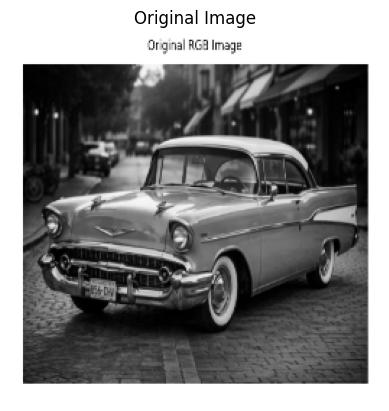

In [ ]:
img = cv2.imread(list(uploaded.keys())[0], cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256,256))

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

Add Degradation (Noise + Blur + Motion)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

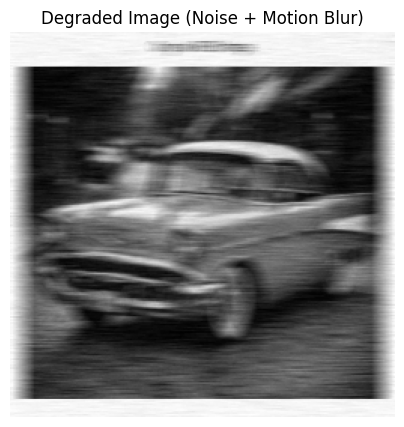

In [ ]:
# Add Gaussian noise
noisy = util.random_noise(img, mode='gaussian', var=0.01)

# Motion blur kernel
kernel_size = 15
kernel_motion = np.zeros((kernel_size, kernel_size))
kernel_motion[int((kernel_size-1)/2), :] = np.ones(kernel_size)
kernel_motion = kernel_motion / kernel_size

motion_blur = cv2.filter2D(noisy, -1, kernel_motion)

# Convert to uint8 for OpenCV filters
degraded = np.uint8(255 * motion_blur)

plt.figure(figsize=(5,5))
plt.imshow(degraded, cmap='gray')
plt.title("Degraded Image (Noise + Motion Blur)")
plt.axis('off')


Apply Restoration Filters

In [ ]:
# Mean filter
mean_filtered = cv2.blur(degraded, (3,3))

# Median filter
median_filtered = cv2.medianBlur(degraded, 3)

# Max filter (dilation)
kernel = np.ones((3,3), np.uint8)
max_filtered = cv2.dilate(degraded, kernel)

# Wiener filter (adaptive)
wiener_filtered = restoration.wiener(degraded, kernel_motion, balance=0.1)

# Inverse filter (in frequency domain)
def inverse_filter(img, kernel, eps=1e-3):
    img_f = np.fft.fft2(img)
    kernel_padded = np.zeros_like(img)
    kh, kw = kernel.shape
    kernel_padded[:kh, :kw] = kernel
    kernel_f = np.fft.fft2(kernel_padded)
    kernel_f[np.abs(kernel_f) < eps] = eps
    result_f = img_f / kernel_f
    result = np.abs(np.fft.ifft2(result_f))
    return result

inverse_filtered = inverse_filter(degraded, kernel_motion)

# Convert Wiener result to uint8 range
wiener_filtered = np.clip(wiener_filtered, 0, 255)


Evaluation Metrics (MSE, PSNR, SSIM)

In [ ]:
def evaluate(original, restored, name):
    mse = mean_squared_error(original, restored)
    psnr = peak_signal_noise_ratio(original, restored, data_range=255)
    ssim = structural_similarity(original, restored, data_range=255)
    print(f"{name}: MSE={mse:.2f}, PSNR={psnr:.2f}, SSIM={ssim:.4f}")

# Convert original to uint8 if needed
original_u8 = np.uint8(img)

print("Evaluation Results:\n")
evaluate(original_u8, mean_filtered, "Mean Filter")
evaluate(original_u8, median_filtered, "Median Filter")
evaluate(original_u8, max_filtered, "Max Filter")
evaluate(original_u8, np.uint8(inverse_filtered), "Inverse Filter")
evaluate(original_u8, np.uint8(wiener_filtered), "Wiener Filter")


Evaluation Results:

Mean Filter: MSE=941.72, PSNR=18.39, SSIM=0.5556
Median Filter: MSE=867.40, PSNR=18.75, SSIM=0.5693
Max Filter: MSE=1353.10, PSNR=16.82, SSIM=0.4965
Inverse Filter: MSE=13403.22, PSNR=6.86, SSIM=0.0067
Wiener Filter: MSE=18837.07, PSNR=5.38, SSIM=0.0361


Visual Comparison

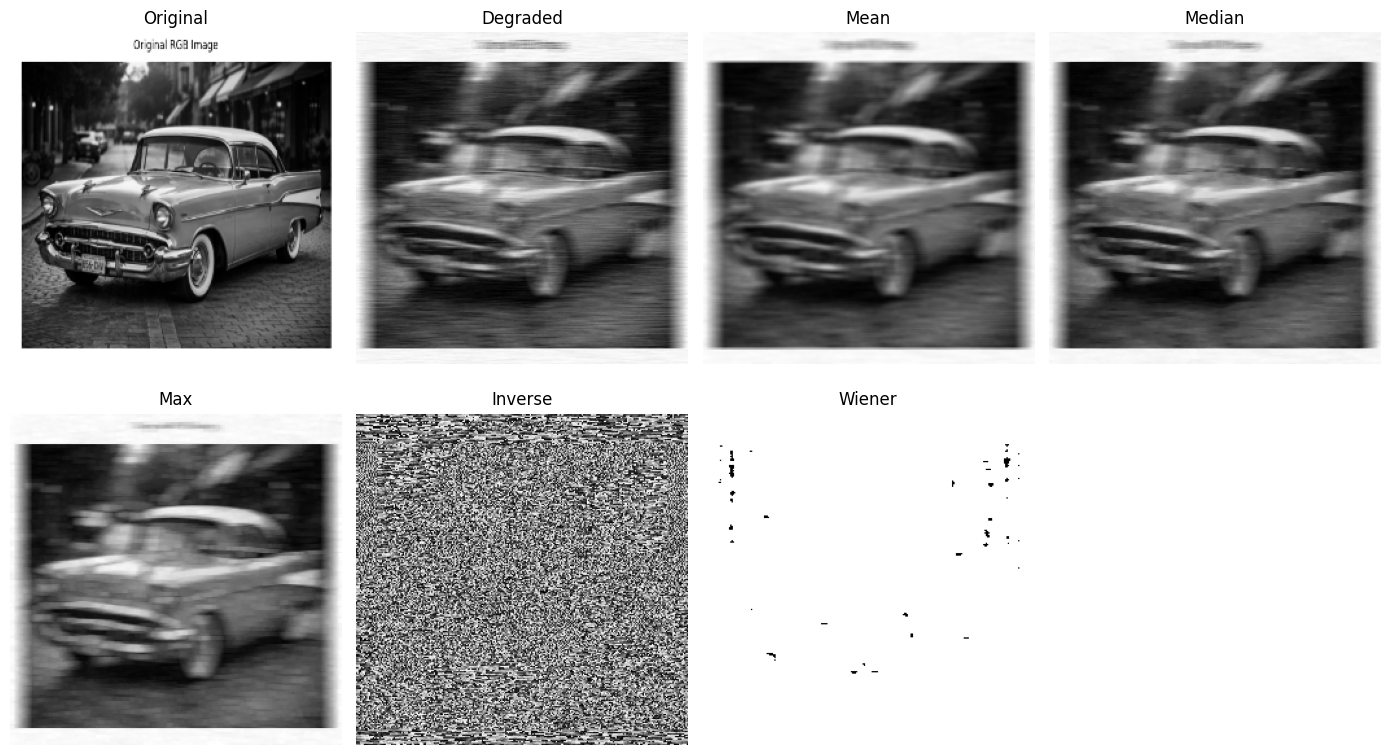

In [ ]:
titles = ["Original", "Degraded", "Mean", "Median", "Max", "Inverse", "Wiener"]
images = [original_u8, degraded, mean_filtered, median_filtered, max_filtered,
          np.uint8(inverse_filtered), np.uint8(wiener_filtered)]

plt.figure(figsize=(14,8))
for i in range(len(images)):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


Convolution Function

In [ ]:
def convolve2d(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i,j] = np.sum(region * kernel)

    # Normalize to 0–255
    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)


Point Detection (FROM SCRATCH)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

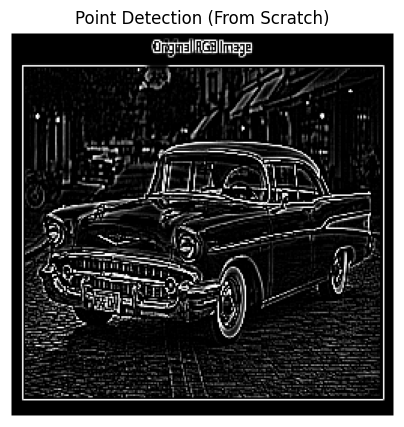

In [ ]:
point_kernel = np.array([[-1,-1,-1],
                          [-1, 8,-1],
                          [-1,-1,-1]])

point_detected = convolve2d(img, point_kernel)

plt.figure(figsize=(5,5))
plt.imshow(point_detected, cmap='gray')
plt.title("Point Detection (From Scratch)")
plt.axis('off')


#Line Detection (FROM SCRATCH)

1. Horizontal lines

In [ ]:
line_h_kernel = np.array([[-1,-1,-1],
                          [ 2, 2, 2],
                          [-1,-1,-1]])

line_h = convolve2d(img, line_h_kernel)


2. Horizontal lines

In [ ]:
line_v_kernel = np.array([[-1, 2,-1],
                          [-1, 2,-1],
                          [-1, 2,-1]])

line_v = convolve2d(img, line_v_kernel)


3. 45-degree lines

In [ ]:
line_45_kernel = np.array([[-1,-1, 2],
                           [-1, 2,-1],
                           [ 2,-1,-1]])

line_45 = convolve2d(img, line_45_kernel)


Display Images

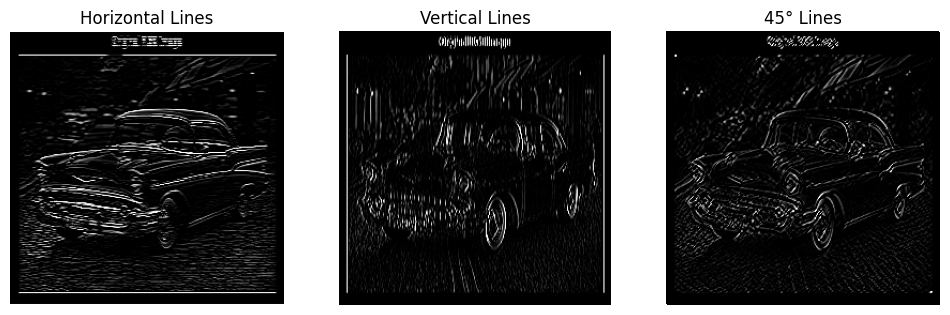

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(line_h, cmap='gray'); plt.title("Horizontal Lines"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(line_v, cmap='gray'); plt.title("Vertical Lines"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(line_45, cmap='gray'); plt.title("45° Lines"); plt.axis('off')
plt.show()


Edge Detection (FROM SCRATCH – Sobel)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

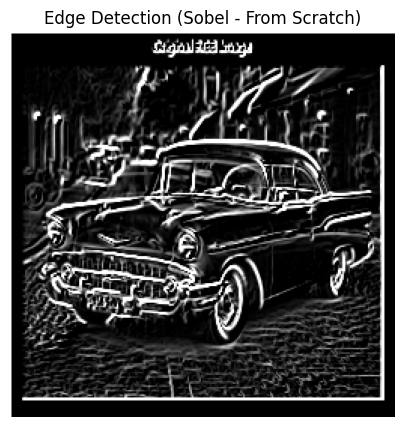

In [ ]:
sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]])

sobel_y = np.array([[-1,-2,-1],
                    [ 0, 0, 0],
                    [ 1, 2, 1]])

gx = convolve2d(img, sobel_x)
gy = convolve2d(img, sobel_y)

# Gradient magnitude
edge_scratch = np.sqrt(gx.astype(np.float32)**2 + gy.astype(np.float32)**2)
edge_scratch = np.clip(edge_scratch, 0, 255).astype(np.uint8)

plt.figure(figsize=(5,5))
plt.imshow(edge_scratch, cmap='gray')
plt.title("Edge Detection (Sobel - From Scratch)")
plt.axis('off')


Same Operations Using OpenCV (For Comparison)

In [ ]:
# Point (Laplacian)
laplacian_cv = cv2.Laplacian(img, cv2.CV_64F)
laplacian_cv = np.uint8(np.abs(laplacian_cv))

# Lines (using Sobel as example)
sobelx_cv = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely_cv = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
edge_cv = cv2.magnitude(sobelx_cv, sobely_cv)
edge_cv = np.uint8(np.clip(edge_cv, 0, 255))

# Canny edge detection
canny = cv2.Canny(img, 100, 200)


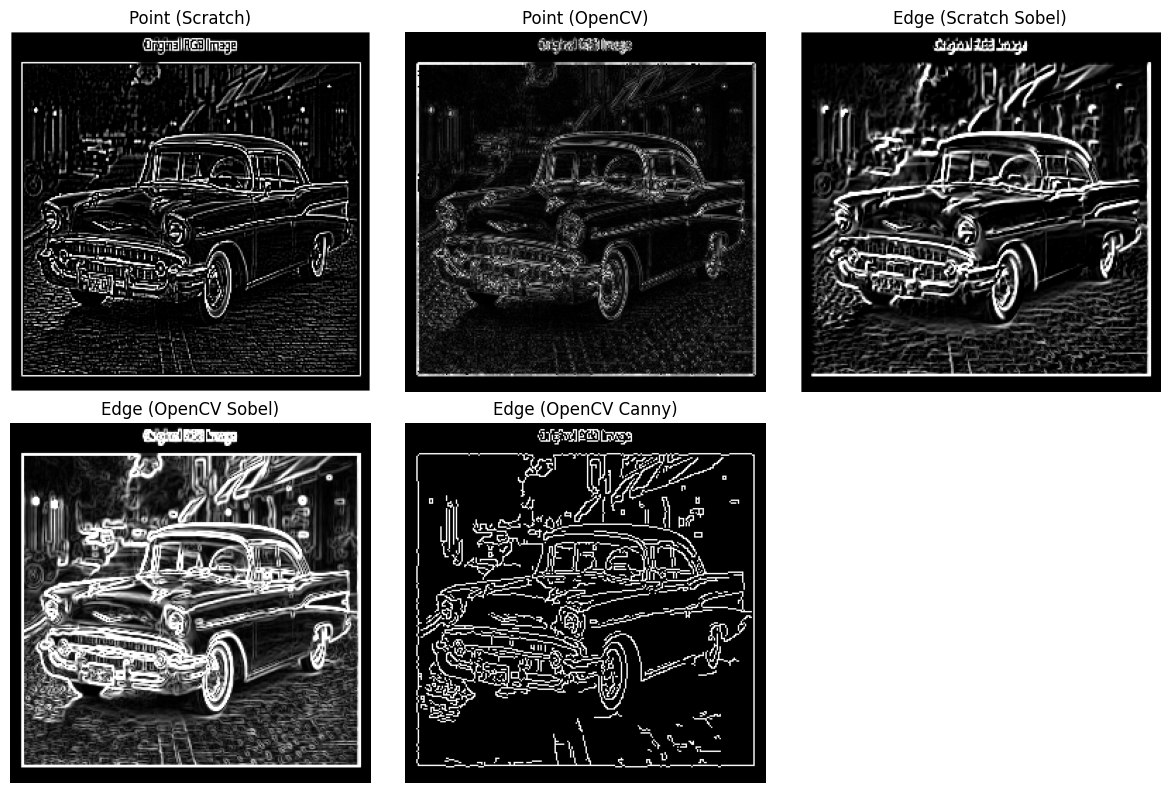

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1); plt.imshow(point_detected, cmap='gray'); plt.title("Point (Scratch)"); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(laplacian_cv, cmap='gray'); plt.title("Point (OpenCV)"); plt.axis('off')

plt.subplot(2,3,3); plt.imshow(edge_scratch, cmap='gray'); plt.title("Edge (Scratch Sobel)"); plt.axis('off')
plt.subplot(2,3,4); plt.imshow(edge_cv, cmap='gray'); plt.title("Edge (OpenCV Sobel)"); plt.axis('off')

plt.subplot(2,3,5); plt.imshow(canny, cmap='gray'); plt.title("Edge (OpenCV Canny)"); plt.axis('off')

plt.tight_layout()
plt.show()


#Segmentation

1. Segmentation using Thresholding


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

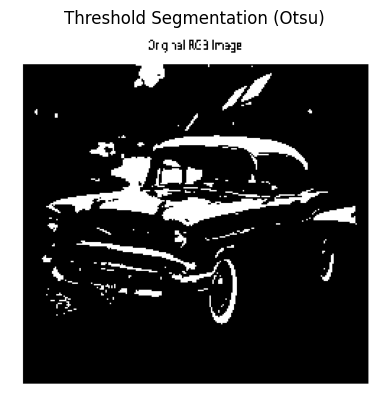

In [ ]:
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold Segmentation (Otsu)")
plt.axis('off')

2. Segmentation using K-Means

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

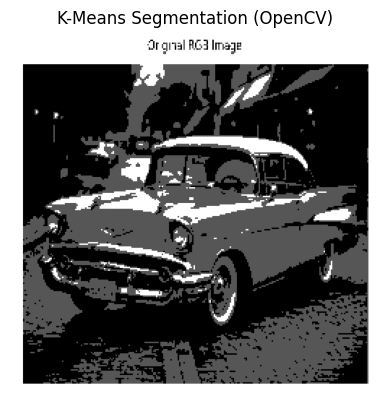

In [ ]:
# Reshape image to 2D array of pixels
Z = img.reshape((-1,1))
Z = np.float32(Z)

# Define criteria and apply kmeans
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
ret,label,center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Convert back to uint8 and reshape
center = np.uint8(center)
segmented_kmeans = center[label.flatten()]
segmented_kmeans = segmented_kmeans.reshape(img.shape)

plt.imshow(segmented_kmeans, cmap='gray')
plt.title("K-Means Segmentation (OpenCV)")
plt.axis('off')

#Final Comparison View

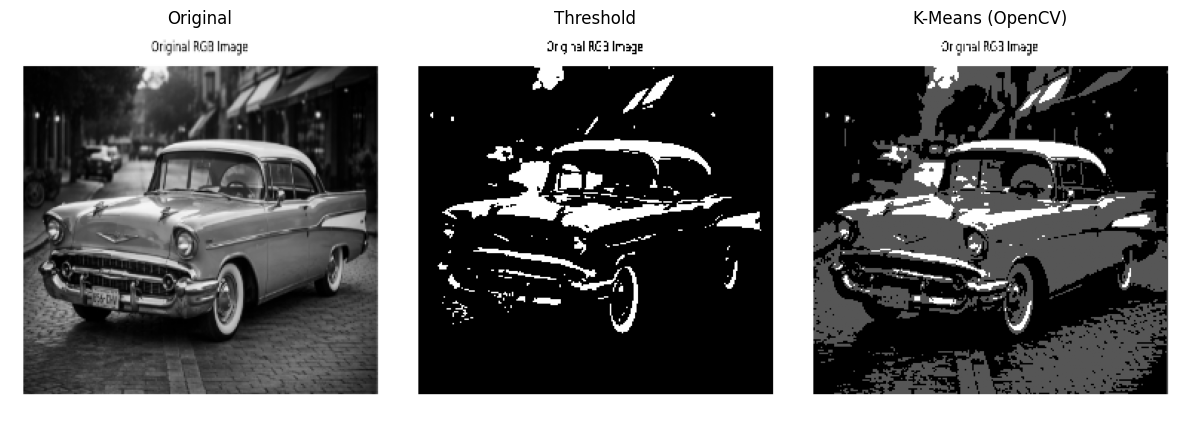

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(thresh, cmap='gray'); plt.title("Threshold"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(segmented_kmeans, cmap='gray'); plt.title("K-Means (OpenCV)"); plt.axis('off')

plt.tight_layout()
plt.show()

#Conclusion

In this experiment, point detection, line detection, and edge detection were successfully implemented using both from-scratch convolution methods and OpenCV-based functions. Point detection using the Laplacian mask effectively highlighted isolated intensity variations in the image. Line detection using directional masks was able to extract horizontal, vertical, and diagonal line structures, demonstrating how spatial filtering can emphasize specific geometric features. Edge detection using the Sobel operator accurately detected intensity discontinuities, which correspond to object boundaries in the image.

The from-scratch implementation provided a clear understanding of how convolution and filtering operate at the pixel level, while the OpenCV implementations offered faster and more optimized results with similar visual outcomes. Overall, the experiment shows that spatial domain filtering is a powerful technique for feature extraction in degraded or low-quality images and plays a crucial role in applications such as surveillance, object detection, and image enhancement.